In [46]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# fetch dataset 
appliances_energy_prediction = fetch_ucirepo(id=374) 
  
# Gộp Features (X) và Targets (y) thành một df duy nhất
X = appliances_energy_prediction.data.features
y = appliances_energy_prediction.data.targets
df = pd.concat([X, y], axis=1)

# Data Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non-null  float64
 19  RH_9         19

In [7]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d%H:%M:%S')
print("- Data type sau khi ép kiểu của cột 'date':", df['date'].dtype)
print("\n- Xem thử thông tin kiểu dữ liệu (5 cột đầu):")
print(df.dtypes.head(5), "\n")

- Data type sau khi ép kiểu của cột 'date': datetime64[us]

- Xem thử thông tin kiểu dữ liệu (5 cột đầu):
date      datetime64[us]
lights             int64
T1               float64
RH_1             float64
T2               float64
dtype: object 



In [6]:
display(df.describe())

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,19.592106,...,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033,97.694958
std,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,1.844623,...,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634,102.524891
min,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,15.330000,...,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322,10.000000
25%,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,18.277500,...,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889,50.000000
50%,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,19.390000,...,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653,60.000000
75%,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,20.619643,...,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769,100.000000
max,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,25.795000,...,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530,1080.000000


In [9]:
# Detect missing values & Percentage of missing per feature
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Total Missing': missing_counts, 
    'Percentage (%)': missing_percentage
})

In [10]:
missing_only = missing_df[missing_df['Total Missing'] > 0]

In [11]:
display(missing_df.head())

,Total Missing,Percentage (%)
date,0,0.0
lights,0,0.0
T1,0,0.0
RH_1,0,0.0
T2,0,0.0


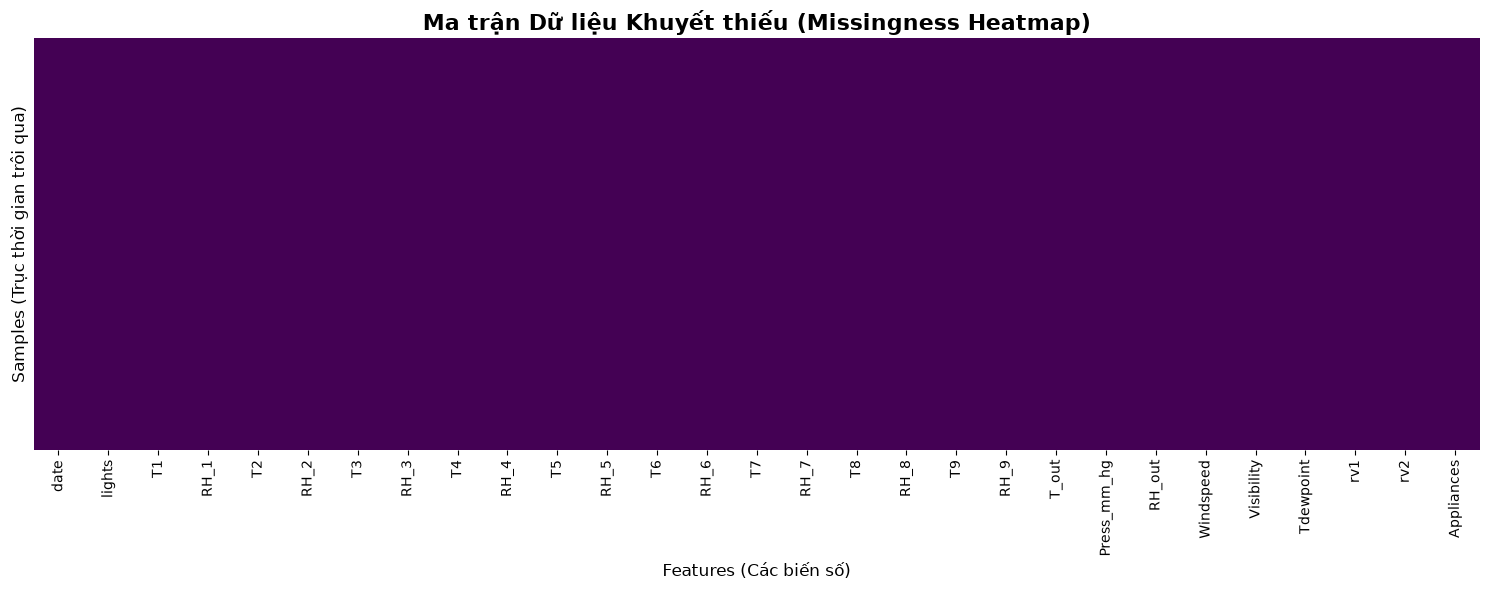

In [12]:
plt.figure(figsize=(15, 6))
# Nền màu tím (viridis) biểu diễn dữ liệu tồn tại, vạch màu vàng biểu diễn dữ liệu khuyết (NaN)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Ma trận Dữ liệu Khuyết thiếu (Missingness Heatmap)', fontsize=16, fontweight='bold')
plt.xlabel('Features (Các biến số)', fontsize=12)
plt.ylabel('Samples (Trục thời gian trôi qua)', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# Trích xuất Giờ trong ngày (0 - 23)
df['hour'] = df['date'].dt.hour

# Trích xuất Ngày trong tuần (0: Thứ hai -> 6: Chủ nhật)
df['day_of_week'] = df['date'].dt.dayofweek

# Trích xuất Tên thứ trong tuần (Monday -> Sunday)
df['day_name'] = df['date'].dt.day_name()

# Trích xuất Trạng thái Ngày thường (0) / Cuối tuần (1)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [14]:
display(df[['date', 'hour', 'day_of_week', 'day_name', 'is_weekend']].head())

,date,hour,day_of_week,day_name,is_weekend
0,2016-01-11 17:00:00,17,0,Monday,0
1,2016-01-11 17:10:00,17,0,Monday,0
2,2016-01-11 17:20:00,17,0,Monday,0
3,2016-01-11 17:30:00,17,0,Monday,0
4,2016-01-11 17:40:00,17,0,Monday,0


In [16]:
print("\nThống kê số lượng mẫu thu thập theo Ngày thường (0) vs Cuối tuần (1):")
print(df['is_weekend'].value_counts().rename(index={0: 'Weekday (Ngày thường)', 1: 'Weekend (Cuối tuần)'}))


Thống kê số lượng mẫu thu thập theo Ngày thường (0) vs Cuối tuần (1):
is_weekend
Weekday (Ngày thường)    14263
Weekend (Cuối tuần)       5472
Name: count, dtype: int64


In [18]:
sns.set_theme(style="whitegrid")

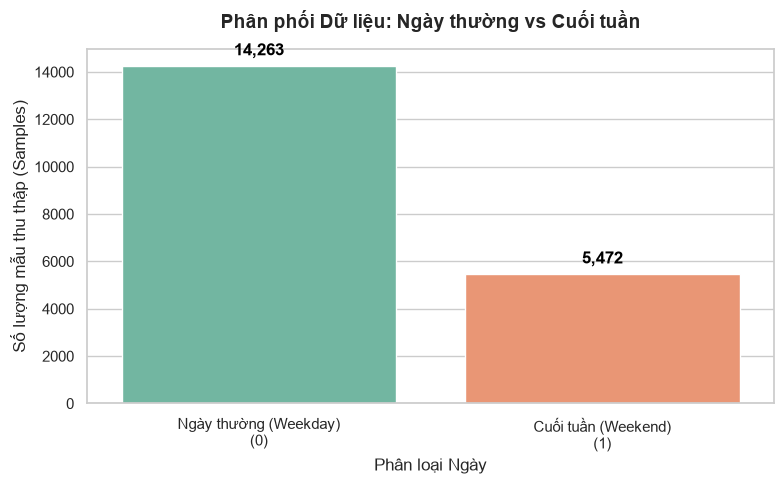

In [20]:
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ cột
ax1 = sns.countplot(data=df, x='is_weekend', palette='Set2', hue='is_weekend', legend=False)
plt.title('Phân phối Dữ liệu: Ngày thường vs Cuối tuần', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Phân loại Ngày', fontsize=12)
plt.ylabel('Số lượng mẫu thu thập (Samples)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Ngày thường (Weekday)\n(0)', 'Cuối tuần (Weekend)\n(1)'])

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', xytext=(0, 5), 
                 textcoords='offset points', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [17]:
print("\nThống kê số lượng mẫu thu thập theo từng Thứ trong tuần:")
print(df['day_name'].value_counts())


Thống kê số lượng mẫu thu thập theo từng Thứ trong tuần:
day_name
Tuesday      2880
Wednesday    2880
Thursday     2880
Friday       2845
Monday       2778
Saturday     2736
Sunday       2736
Name: count, dtype: int64


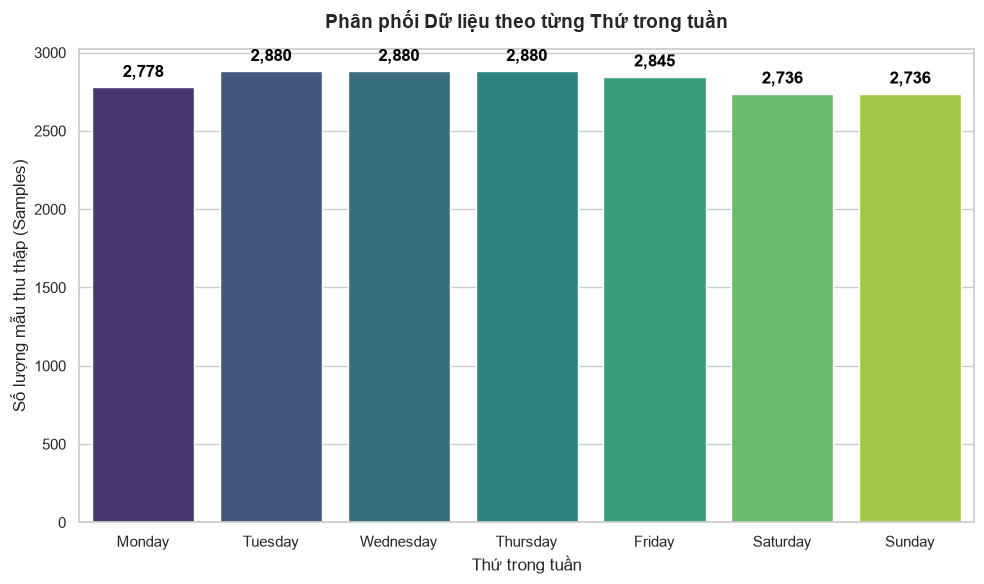

In [22]:
plt.figure(figsize=(10, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Vẽ biểu đồ cột
ax2 = sns.countplot(data=df, x='day_name', order=day_order, palette='viridis', hue='day_name',legend=False)
plt.title('Phân phối Dữ liệu theo từng Thứ trong tuần', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thứ trong tuần', fontsize=12)
plt.ylabel('Số lượng mẫu thu thập (Samples)', fontsize=12)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', xytext=(0, 5), 
                 textcoords='offset points', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# Univariate Analysis

In [24]:
print("Thống kê phân phối Điện năng tiêu thụ (Appliances):")
skewness = df['Appliances'].skew()
print(f"- Độ lệch (Skewness) của Appliances: {skewness:.2f}")

Thống kê phân phối Điện năng tiêu thụ (Appliances):
- Độ lệch (Skewness) của Appliances: 3.39


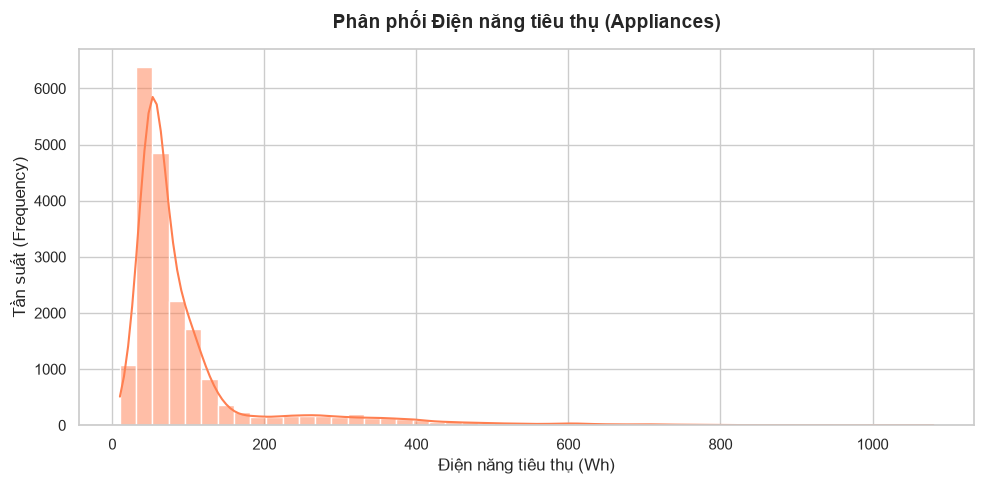

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Appliances'], bins=50, kde=True, color='coral')
plt.title('Phân phối Điện năng tiêu thụ (Appliances)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Điện năng tiêu thụ (Wh)', fontsize=12)
plt.ylabel('Tần suất (Frequency)', fontsize=12)
plt.tight_layout()
plt.show()

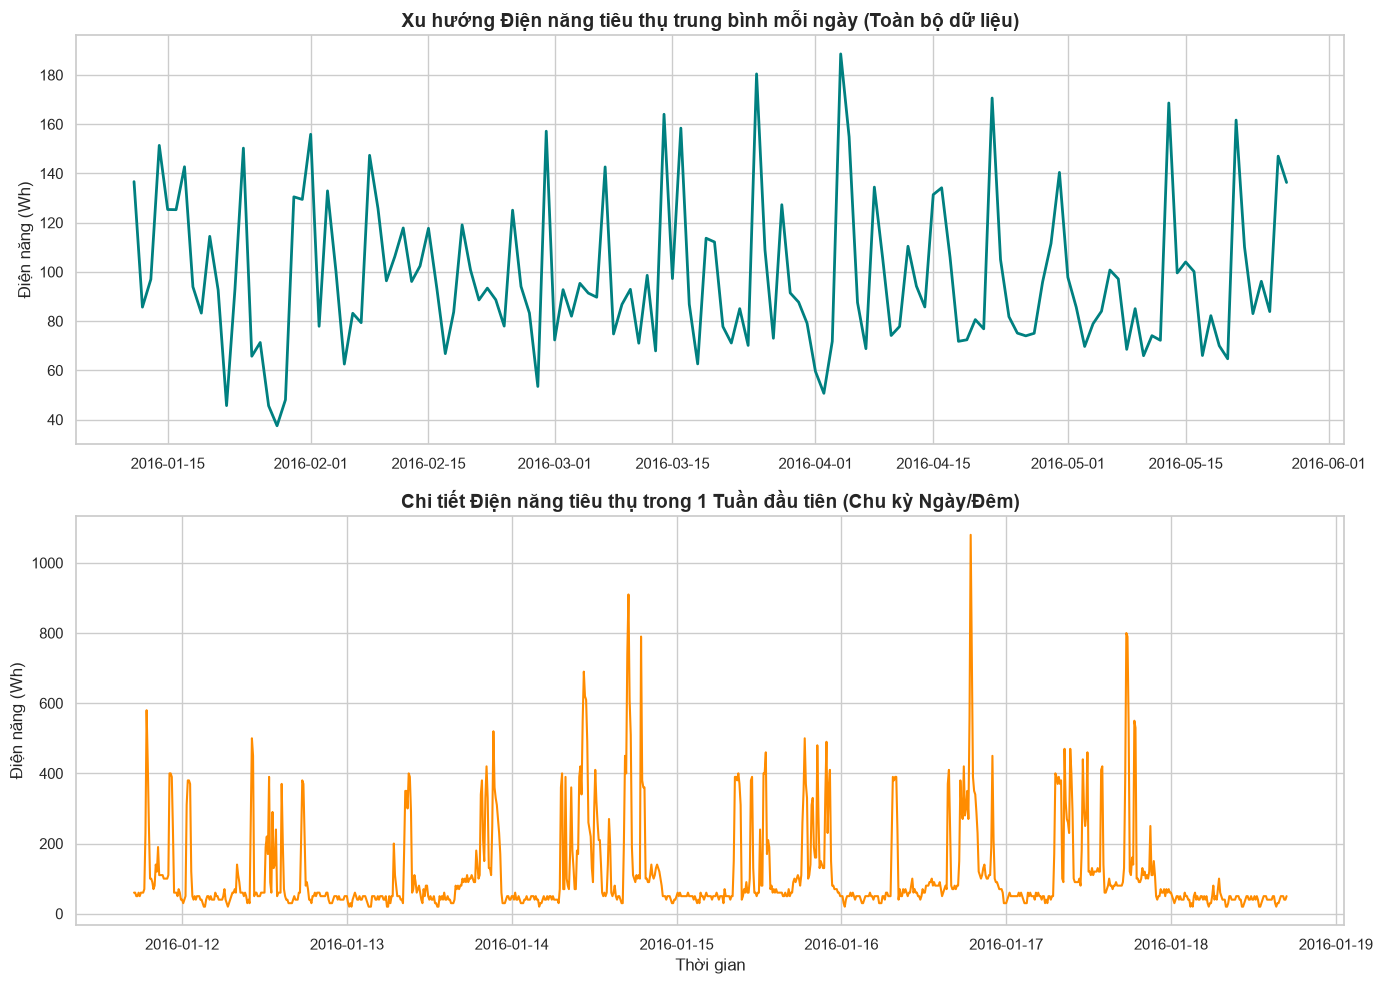

In [26]:
# Tạm thời set cột 'date' làm index để dễ dàng resample (nhóm) theo thời gian
df_time = df.set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Đồ thị 2.1: Xu hướng tổng thể (Trung bình tiêu thụ mỗi ngày)
daily_avg = df_time['Appliances'].resample('D').mean()
axes[0].plot(daily_avg.index, daily_avg.values, color='teal', linewidth=2)
axes[0].set_title('Xu hướng Điện năng tiêu thụ trung bình mỗi ngày (Toàn bộ dữ liệu)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Điện năng (Wh)', fontsize=12)

# Đồ thị 2.2: Tính chu kỳ (Phóng to vào 1 Tuần đầu tiên)
first_week = df_time.head(1008) # 1 tuần = 144 mẫu/ngày * 7 ngày = 1008 mẫu
axes[1].plot(first_week.index, first_week['Appliances'], color='darkorange', linewidth=1.5)
axes[1].set_title('Chi tiết Điện năng tiêu thụ trong 1 Tuần đầu tiên (Chu kỳ Ngày/Đêm)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Điện năng (Wh)', fontsize=12)
axes[1].set_xlabel('Thời gian', fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
print("Tần suất dữ liệu theo từng Khung giờ trong ngày (0-23):")
hour_counts = df['hour'].value_counts().sort_index()
print(hour_counts.to_string())

Tần suất dữ liệu theo từng Khung giờ trong ngày (0-23):
hour
0     822
1     822
2     822
3     822
4     822
5     822
6     822
7     822
8     822
9     822
10    822
11    822
12    822
13    822
14    822
15    822
16    822
17    828
18    823
19    822
20    822
21    822
22    822
23    822


In [29]:
print("Tần suất dữ liệu theo từng Ngày trong tuần:")
day_counts = df['day_name'].value_counts()
print(day_counts.to_string())

Tần suất dữ liệu theo từng Ngày trong tuần:
day_name
Tuesday      2880
Wednesday    2880
Thursday     2880
Friday       2845
Monday       2778
Saturday     2736
Sunday       2736


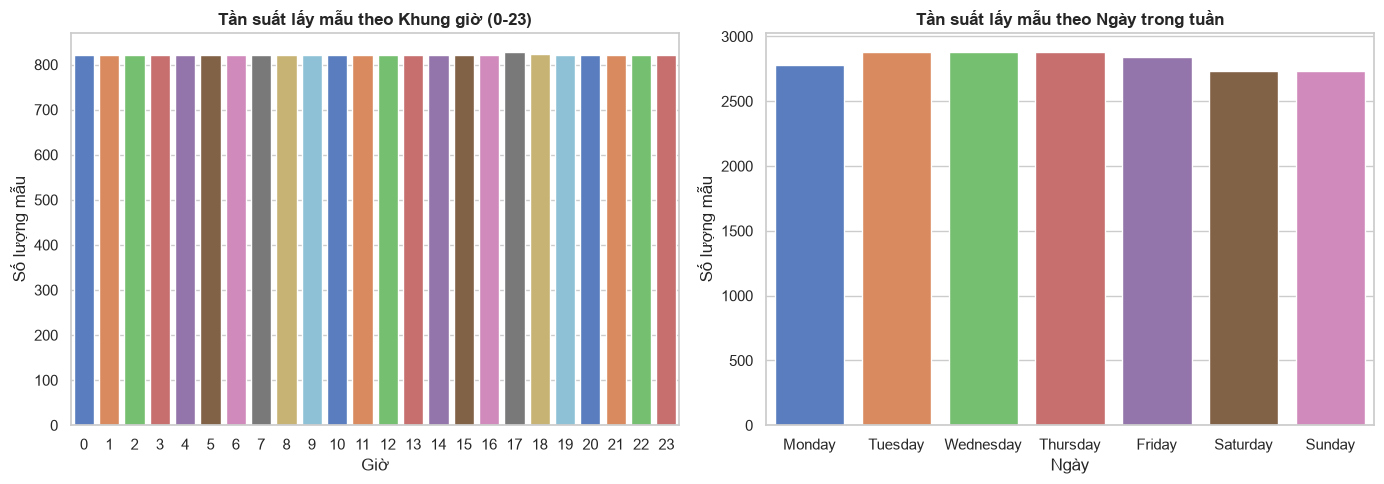

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='hour', palette='muted', ax=axes[0],hue='hour',legend=False)
axes[0].set_title('Tần suất lấy mẫu theo Khung giờ (0-23)', fontweight='bold')
axes[0].set_xlabel('Giờ')
axes[0].set_ylabel('Số lượng mẫu')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='day_name', order=day_order, palette='muted', ax=axes[1], hue='day_name', legend=False)
axes[1].set_title('Tần suất lấy mẫu theo Ngày trong tuần', fontweight='bold')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Số lượng mẫu')

plt.tight_layout()
plt.show()

# Bivariate / Multivariate Analysis

## NUMERICAL VS NUMERICAL

In [32]:
# Lọc ra các cột numerical chính (cảm biến + target)
sensor_cols = [col for col in df.columns if col not in ['date', 'day_name', 'hour', 'day_of_week', 'is_weekend']]
corr_matrix = df[sensor_cols].corr()

In [33]:
top_corr_target = corr_matrix['Appliances'].drop('Appliances').abs().sort_values(ascending=False).head(5)
print("Top 5 biến cảm biến có tương quan mạnh nhất với 'Appliances' (trị tuyệt đối):")
print(top_corr_target.to_string())

Top 5 biến cảm biến có tương quan mạnh nhất với 'Appliances' (trị tuyệt đối):
lights    0.197278
RH_out    0.152282
T2        0.120073
T6        0.117638
T_out     0.099155


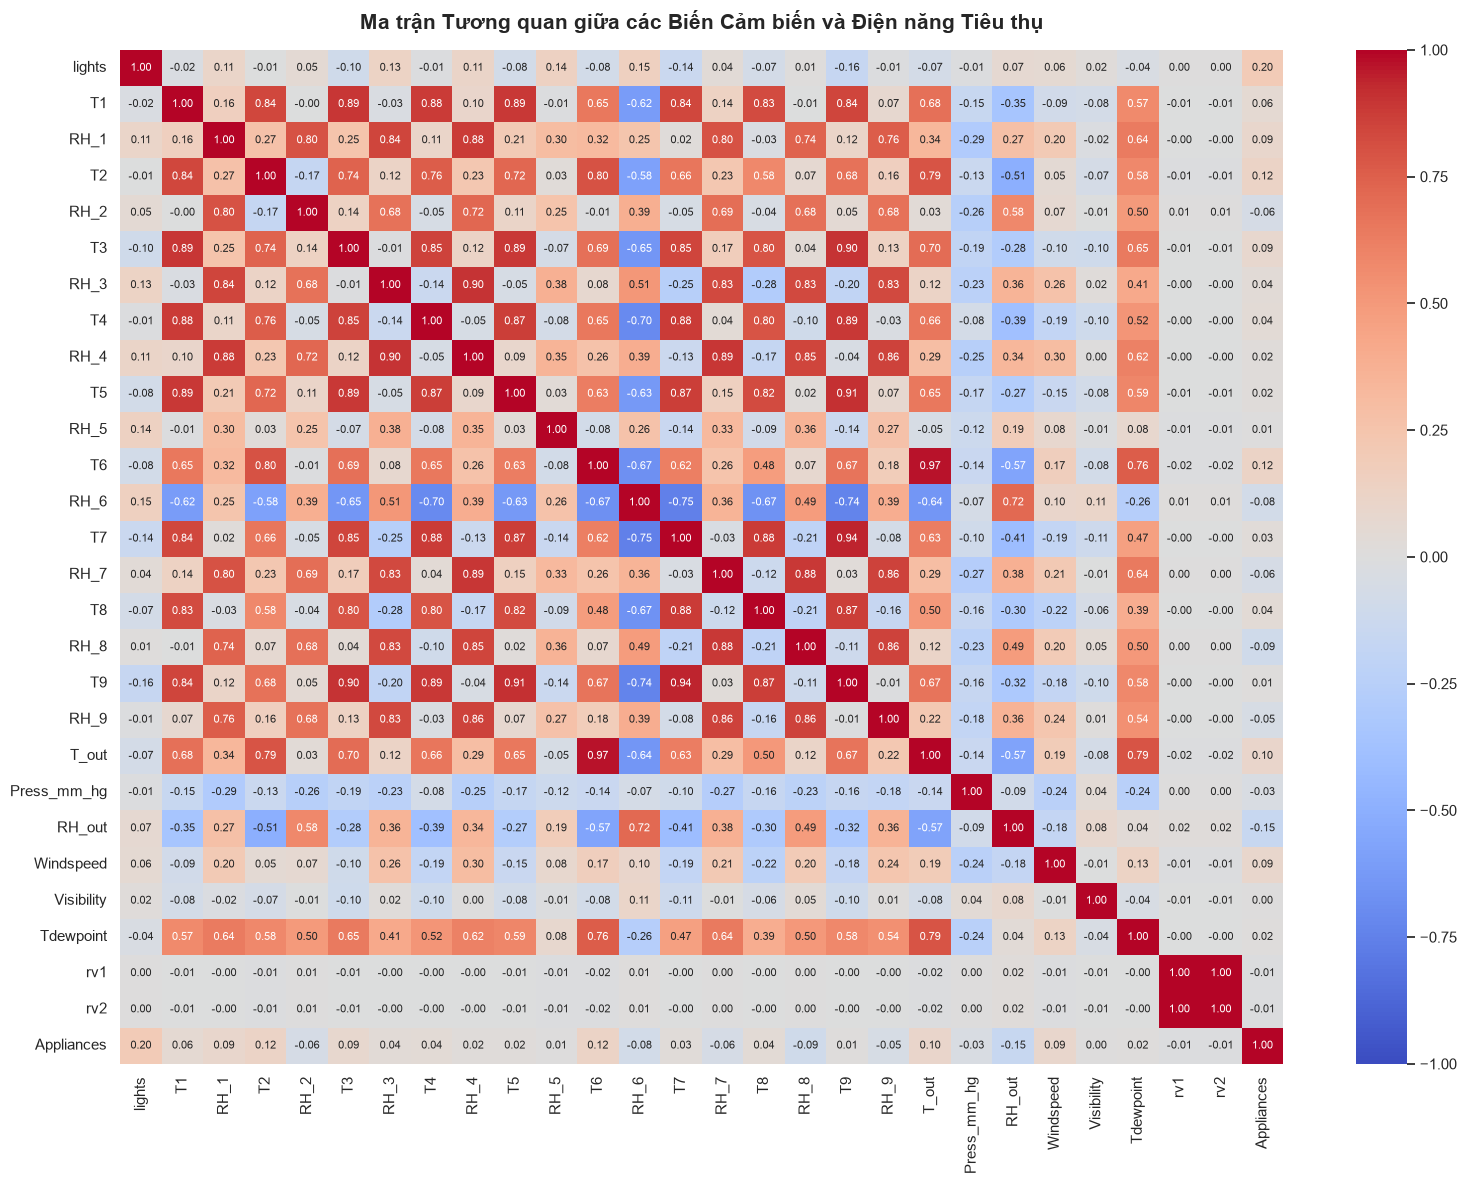

In [35]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True, annot_kws={"size": 8})
plt.title('Ma trận Tương quan giữa các Biến Cảm biến và Điện năng Tiêu thụ', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [36]:
top_feature = top_corr_target.index[0] # Biến tương quan cao nhất
second_top_feature = top_corr_target.index[1]

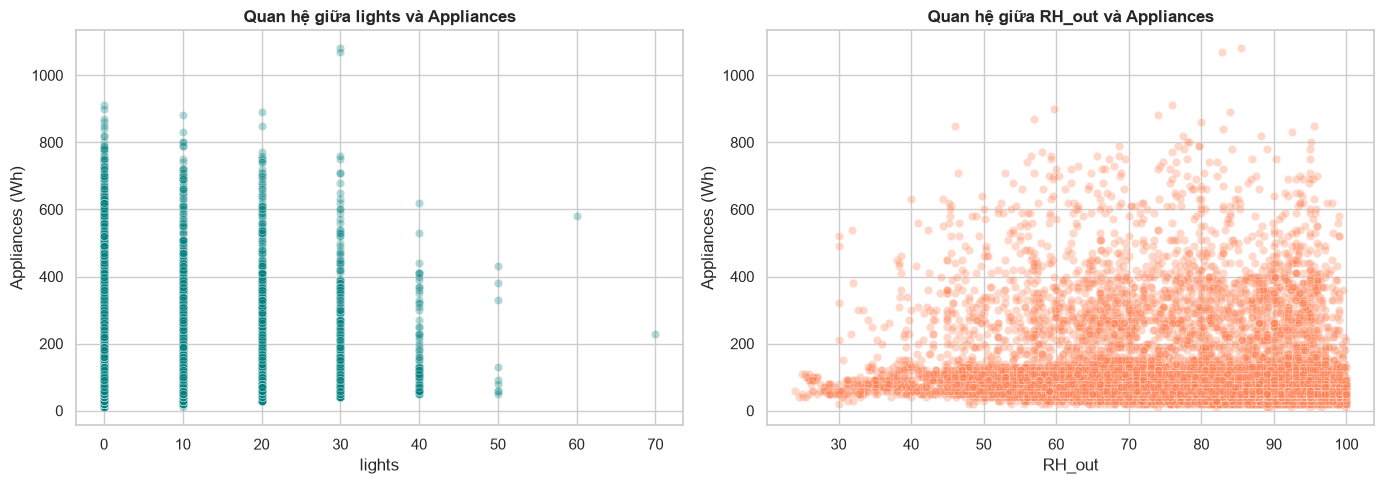

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x=top_feature, y='Appliances', alpha=0.3, color='teal', ax=axes[0])
axes[0].set_title(f'Quan hệ giữa {top_feature} và Appliances', fontweight='bold')
axes[0].set_ylabel('Appliances (Wh)')

sns.scatterplot(data=df, x=second_top_feature, y='Appliances', alpha=0.3, color='coral', ax=axes[1])
axes[1].set_title(f'Quan hệ giữa {second_top_feature} và Appliances', fontweight='bold')
axes[1].set_ylabel('Appliances (Wh)')

plt.tight_layout()
plt.show()

In [38]:
def calc_cross_corr(series1, series2, max_lag=24):
    lags = range(-max_lag, max_lag + 1)
    corrs = [series1.corr(series2.shift(lag)) for lag in lags]
    return list(lags), corrs

In [39]:
# Tính tương quan chéo giữa biến cảm biến hàng đầu và Appliances trong 24 bước thời gian (240 phút = 4 tiếng)
lags, ccf_values = calc_cross_corr(df[top_feature], df['Appliances'], max_lag=24)

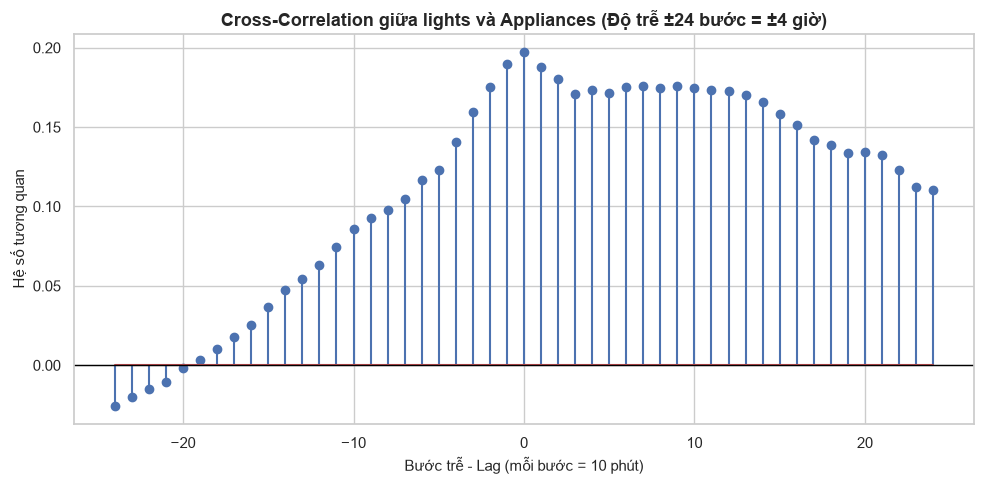

In [41]:
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_values)
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Cross-Correlation giữa {top_feature} và Appliances (Độ trễ ±24 bước = ±4 giờ)', fontsize=13, fontweight='bold')
plt.xlabel('Bước trễ - Lag (mỗi bước = 10 phút)', fontsize=11)
plt.ylabel('Hệ số tương quan', fontsize=11)
plt.tight_layout()
plt.show()

## CATEGORICAL VS NUMERICAL

C:\Users\minhchi\AppData\Local\Temp\ipykernel_9924\3170977618.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Weekday (0)', 'Weekend (1)'])


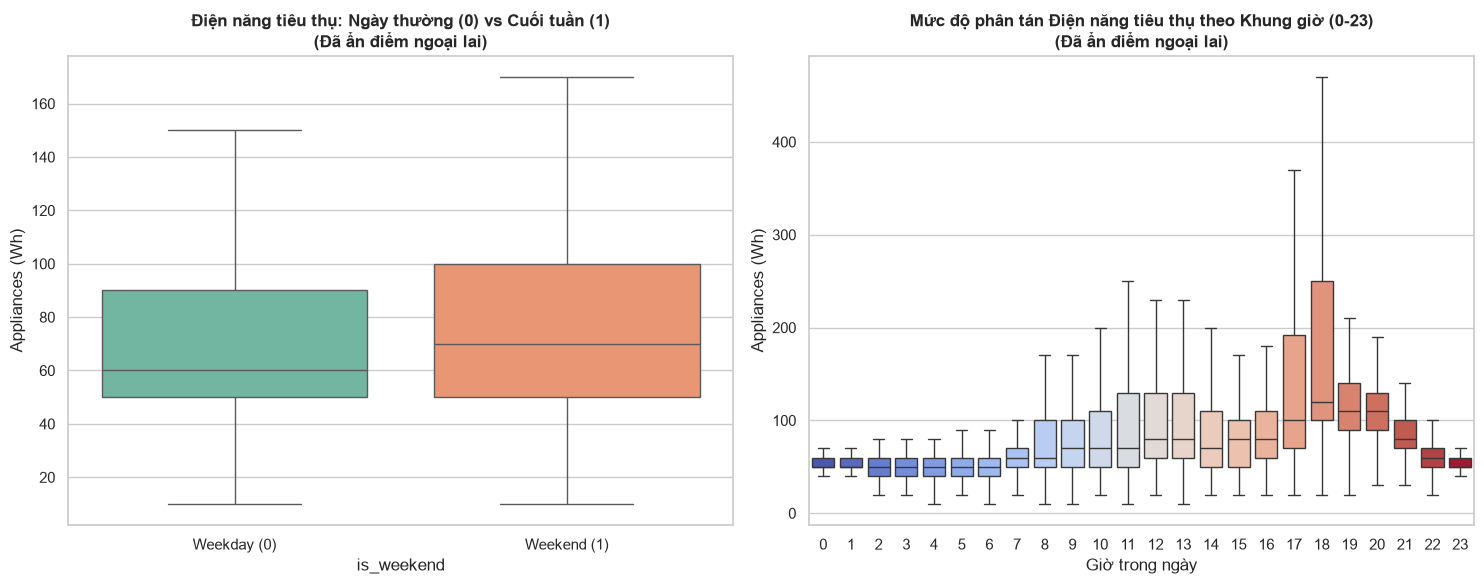

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1: Ngày thường (0) vs Cuối tuần (1)
sns.boxplot(data=df, x='is_weekend', y='Appliances', palette='Set2', ax=axes[0], showfliers=False, hue='is_weekend', legend=False)
axes[0].set_title('Điện năng tiêu thụ: Ngày thường (0) vs Cuối tuần (1)\n(Đã ẩn điểm ngoại lai)', fontweight='bold')
axes[0].set_xticklabels(['Weekday (0)', 'Weekend (1)'])
axes[0].set_ylabel('Appliances (Wh)')

# Boxplot 2: Điện năng tiêu thụ theo Khung giờ trong ngày (0-23)
sns.boxplot(data=df, x='hour', y='Appliances', palette='coolwarm', ax=axes[1], showfliers=False,hue='hour',legend=False)
axes[1].set_title('Mức độ phân tán Điện năng tiêu thụ theo Khung giờ (0-23)\n(Đã ẩn điểm ngoại lai)', fontweight='bold')
axes[1].set_xlabel('Giờ trong ngày')
axes[1].set_ylabel('Appliances (Wh)')

plt.tight_layout()
plt.show()

In [45]:
print("Bảng thống kê lượng điện trung bình theo Ngày thường vs Cuối tuần:")
print(df.groupby('is_weekend')['Appliances'].describe().rename(index={0: 'Weekday', 1: 'Weekend'}))

Bảng thống kê lượng điện trung bình theo Ngày thường vs Cuối tuần:
              count        mean         std   min   25%   50%    75%     max
is_weekend                                                                  
Weekday     14263.0   96.587674  103.086372  10.0  50.0  60.0   90.0  1070.0
Weekend      5472.0  100.581140  100.998987  10.0  50.0  70.0  100.0  1080.0


# Outlier Detection

In [47]:
sensor_cols = [col for col in df.columns if col.startswith('T') or col.startswith('RH') or col in ['Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint']]

In [48]:
def count_outliers_iqr(dataframe, columns):
    outlier_counts = {}
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
    return outlier_counts

In [51]:
print("Thống kê số lượng điểm Outlier trên các cảm biến:")
outliers_dict = count_outliers_iqr(df, sensor_cols)
outliers_df = pd.DataFrame(list(outliers_dict.items()), columns=['Feature', 'Outlier Count'])
outliers_df['Percentage (%)'] = (outliers_df['Outlier Count'] / len(df)) * 100

top_outliers = outliers_df.sort_values(by='Outlier Count', ascending=False).head(5)
display(top_outliers)

Thống kê số lượng điểm Outlier trên các cảm biến:


,Feature,Outlier Count,Percentage (%)
22,Visibility,2522,12.779326
9,RH_5,1330,6.739296
2,T2,546,2.766658
0,T1,515,2.609577
10,T6,515,2.609577


In [52]:
df_cleaned = df.copy()

for col in sensor_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Thay thế các điểm nằm ngoài ranh giới IQR bằng NaN
    df_cleaned[col] = np.where((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound), np.nan, df_cleaned[col])
    
    # Dùng nội suy tuyến tính lấp đầy các khoảng NaN dựa vào trục thời gian
    df_cleaned[col] = df_cleaned[col].interpolate(method='linear')

print("-> Đã hoàn tất làm mượt dữ liệu cho toàn bộ cảm biến!\n")

-> Đã hoàn tất làm mượt dữ liệu cho toàn bộ cảm biến!



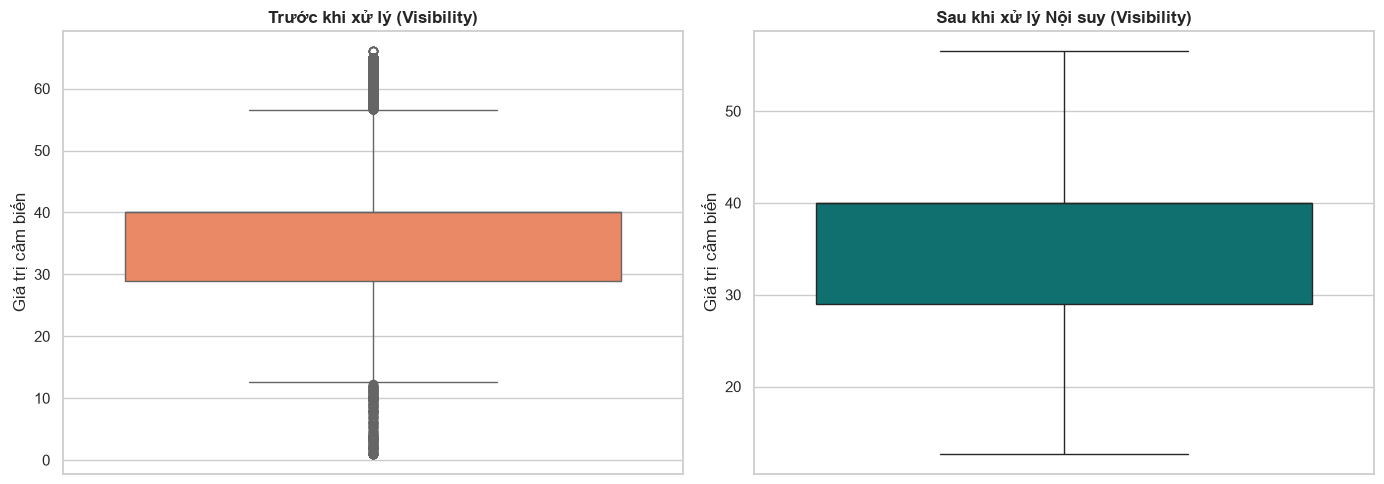

In [53]:
top_col = top_outliers.iloc[0]['Feature']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Trước khi xử lý
sns.boxplot(y=df[top_col], color='coral', ax=axes[0])
axes[0].set_title(f'Trước khi xử lý ({top_col})', fontweight='bold')
axes[0].set_ylabel('Giá trị cảm biến')

# Sau khi xử lý
sns.boxplot(y=df_cleaned[top_col], color='teal', ax=axes[1])
axes[1].set_title(f'Sau khi xử lý Nội suy ({top_col})', fontweight='bold')
axes[1].set_ylabel('Giá trị cảm biến')

plt.tight_layout()
plt.show()